In [1]:
from qiskit import __version__
print(__version__)

2.5.2


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import array_to_latex, plot_histogram
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

## Implementing teleportation protocol

In [3]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

In [4]:
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

### The barrier() function creates a visual separation making the circuit diagram more readable, and it also prevents Qiskit from performing various simplifications and optimizations across the barrier during compilation when circuits are run on real hardware

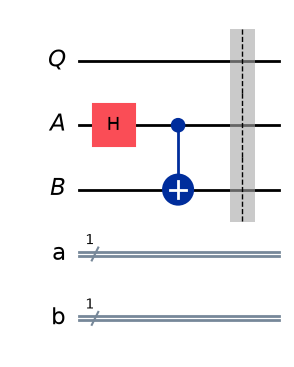

In [5]:
# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

display(protocol.draw(output="mpl"))

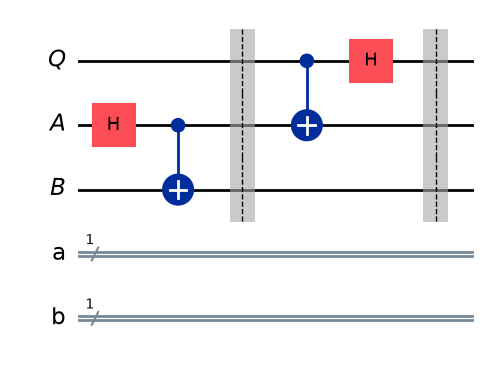

In [6]:
# Alice's operation
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()
display(protocol.draw(output="mpl"))

### The if_test() function applies an operation conditionally depending on a classical bit or register

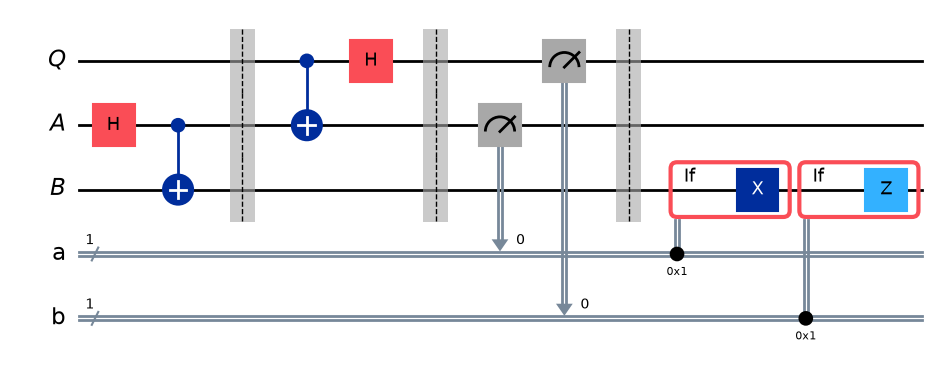

In [7]:
# Alice measures and sends classical bit to bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output="mpl"))

####  To test that the protocol works correctly, we'll apply a randomly generated single-qubit gate to the initialized ∣0⟩ state of Q to obtain a random quantum state vector to be teleported. By applying the inverse (as in, the conjugate transpose) of that gate to B after the protocol is run, we can verify that the state was teleported by measuring to see that it has returned to the ∣0⟩ state.

In [8]:
random_gate = UGate(
    theta = random.random() * 2 * pi,
    phi = random.random() * 2 * pi,
    lam = random.random() * 2 * pi
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

#### Now we'll create a new testing circuit that first applies our random gate to Q then runs the teleportation circuit, and finally applies the inverse of our random gate to the qubit B and measures. The outcome should be 0 with certainty.



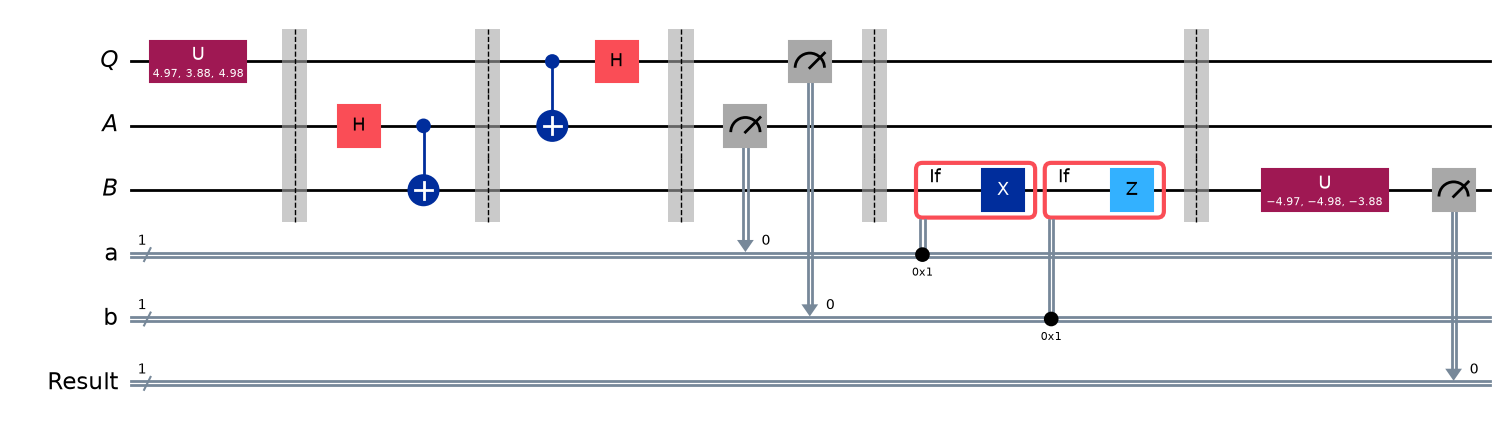

In [9]:
# Create a new circuit including the same bits and qubits used in the teleportation protocol.
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q
test.append(random_gate, qubit)
test.barrier()

# Append the entire teleportation protocol from above.
test = test.compose(protocol)
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)
display(test.draw(output="mpl"))

#### Finally, let's run the Aer simulator on this circuit and plot a histogram of the outputs. We'll see the statistics for all three classical bits: the bottom/leftmost bit should always be 0, indicating that the qubit Q was successfully teleported into B, while the other two bits should be roughly uniform.

In [10]:
result = AerSimulator().run(test).result()

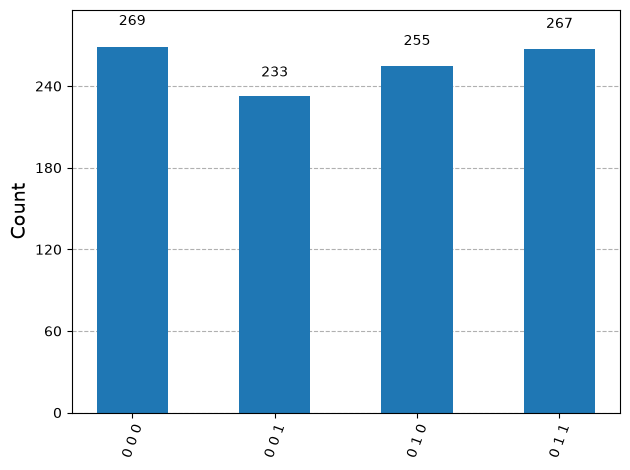

In [11]:
statistics = result.get_counts()
display(plot_histogram(statistics))

#### We can also filter the statistics to focus solely on the test result qubit if we wish using marginal distribution

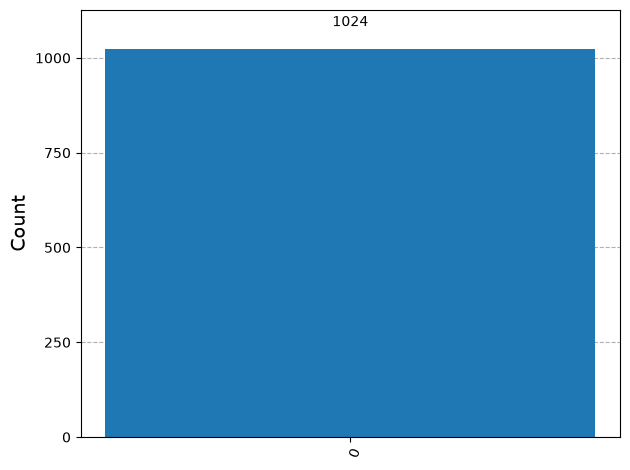

In [12]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

## Superdense Coding

In [13]:
# two bits to transfer
c = "1"
d = "0"

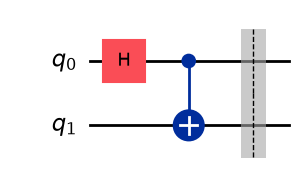

In [14]:
protocol = QuantumCircuit(2)

# prepare ebit
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

display(protocol.draw(output="mpl"))

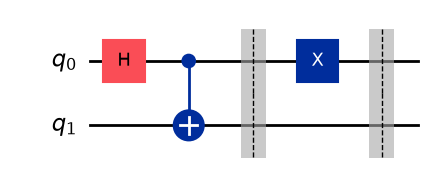

In [15]:
# Alice's operation
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

display(protocol.draw(output="mpl"))

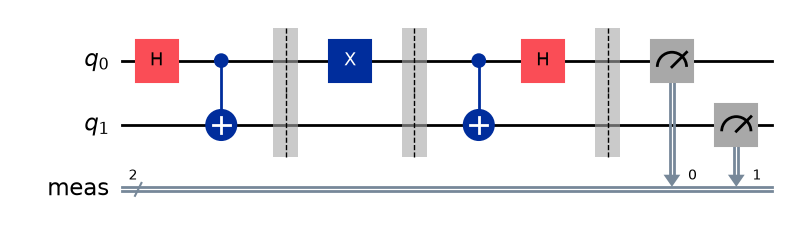

In [16]:
# Bob's operation
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

#### running AerSimulator to see the result

measured 10 with frequency 1024


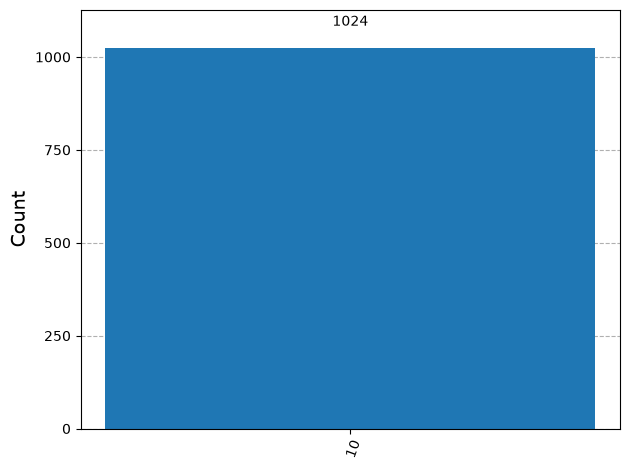

In [17]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"measured {outcome} with frequency {frequency}")

plot_histogram(statistics)

### Now let's use an additional qubit as a random bit generator — essentially to flip fair coins. We'll use it to randomly choose c and d, and then run the superdense coding protocol.

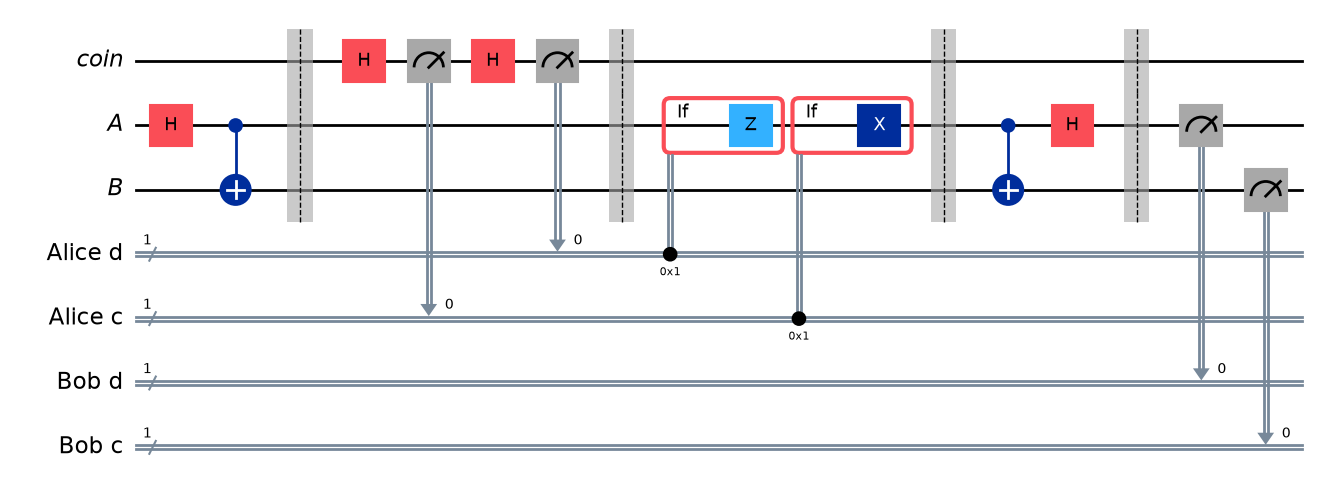

In [18]:
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# intialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# using "coin" qubit to randomly generate alice classical bits
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Alice's action
with test.if_test((Alice_d, 1)):
    test.z(ebit0)
with test.if_test((Alice_c, 1)):
    test.x(ebit0)
test.barrier()

# Bob's action
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))

#### Checking result using Aer simulator

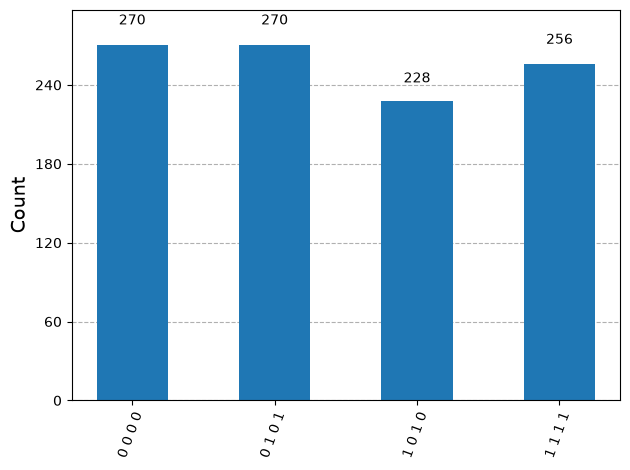

In [19]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
plot_histogram(statistics)

## CHSH Game

In [20]:
def chsh_game(strategy):
    
    # choose x and y randomly
    x, y = random.randint(0, 1), random.randint(0, 1)
    
    # choose a and b using the strategy
    a, b = strategy(x, y)

    # decide if wins or loses
    if (a != b) == (x & y):    # a != b results a xor b 
        return 1 # win
    return 0

#### Now we'll create a function that outputs a circuit depending on the questions for Alice and Bob. we'll use the built-in Ry(θ) gate for Alice and Bob's actions

In [21]:
def chsh_circuit(x, y):
    qc = QuantumCircuit(2, 2)

    # prepare ebit
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Alice's action
    if x == 0:
        qc.ry(0, 0)
    else:
        qc.ry(-pi/2, 0)
    qc.measure(0, 0)

    # Bob's action
    if y == 0:
        qc.ry(-pi/4, 1)
    else:
        qc.ry(pi/4, 1)
    qc.measure(1, 1)

    return qc

#### All different circuits for different x and y

(x, y) = (0, 0)


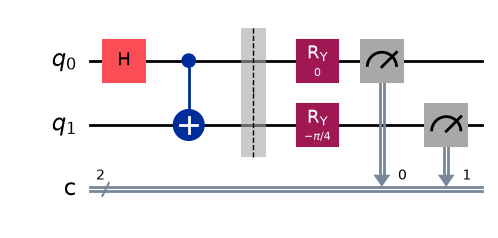

(x, y) = (0, 1)


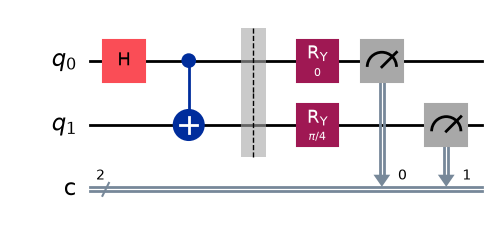

(x, y) = (1, 0)


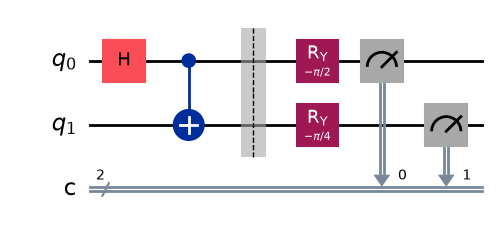

(x, y) = (1, 1)


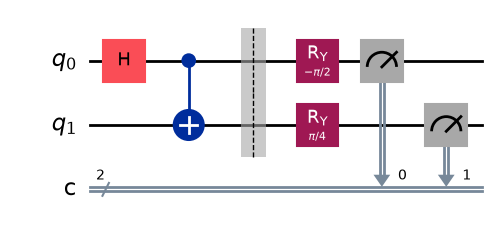

In [22]:
print("(x, y) = (0, 0)")
display(chsh_circuit(0, 0).draw(output="mpl"))

print("(x, y) = (0, 1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x, y) = (1, 0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x, y) = (1, 1)")
display(chsh_circuit(1, 1).draw(output="mpl"))

#### Now we'll create a job using the Aer simulator that runs the circuit a single time for a given input pair (x,y).

In [25]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results

    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

#### Now play the game for 1000 times

In [26]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print(f"fraction of games won: {TOTAL_SCORE/NUM_GAMES}")

fraction of games won: 0.852
